# Model Evaluation & Validation

**Scenario:**  
You have built three different models to predict customer churn. Your manager asks: *"Which model is best?"* This seems simple — but the answer depends on how you measure performance, how you split your data, and whether you are measuring the right thing for the business problem.

This notebook covers everything you need to evaluate models correctly and fairly.

| Section | Topic |
|---|---|
| 1 | The Evaluation Problem — Why We Need Held-Out Data |
| 2 | Train/Test Split — The Right Way |
| 3 | K-Fold Cross-Validation |
| 4 | Stratified & Repeated Cross-Validation |
| 5 | Regression Metrics |
| 6 | Classification Metrics |
| 7 | The ROC/PR Tradeoff — When to Use Which |
| 8 | Calibration — Are Probabilities Trustworthy? |
| 9 | Learning Curves |
| 10 | Validation Curves |
| 11 | Hyperparameter Tuning — Grid vs Random Search |
| 12 | Data Leakage — The Silent Killer |
| 13 | Statistical Significance of Model Differences |
| 14 | Summary — The Evaluation Checklist |

---
## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.model_selection import (
    train_test_split, KFold, StratifiedKFold, RepeatedStratifiedKFold,
    cross_val_score, cross_validate,
    learning_curve, validation_curve,
    GridSearchCV, RandomizedSearchCV
)
from sklearn.metrics import (
    # Regression
    mean_squared_error, mean_absolute_error,
    mean_absolute_percentage_error, r2_score,
    # Classification
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, roc_auc_score,
    precision_recall_curve, average_precision_score,
    brier_score_loss, log_loss,
    classification_report, matthews_corrcoef
)
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (11, 5)
np.random.seed(42)

print('Libraries loaded.')

Libraries loaded.


---
## 1. The Evaluation Problem

**The core problem:** We want to know how well a model performs on **new, unseen data**. But we can only measure performance on data we have.

> Evaluating a model on the same data it was trained on is like giving a student the exam questions before the exam. They score 100% but learn nothing.

**Optimism bias:** A model always performs better on training data than on new data — because it has adapted to the training data's specific patterns, including its noise.

In [2]:
# Build the customer churn dataset
N = 800

tenure_months   = np.random.exponential(24, N).clip(1, 72).round()
monthly_charges = np.random.normal(65, 20, N).clip(20, 120)
num_services    = np.random.randint(1, 8, N).astype(float)
support_calls   = np.random.poisson(1.5, N)
contract_type   = np.random.choice([0, 1, 2], N, p=[0.45, 0.30, 0.25])  # 0=monthly, 1=1yr, 2=2yr

# Churn probability
churn_log_odds = (
    1.5
    - 0.04  * tenure_months
    + 0.02  * monthly_charges
    - 0.15  * num_services
    + 0.30  * support_calls
    - 0.80  * contract_type
    + np.random.normal(0, 0.5, N)
)
churn_prob  = 1 / (1 + np.exp(-churn_log_odds))
churned     = (churn_prob > 0.5).astype(int)

df = pd.DataFrame({
    'tenure':          tenure_months,
    'monthly_charges': monthly_charges.round(2),
    'num_services':    num_services,
    'support_calls':   support_calls,
    'contract_type':   contract_type,
    'churned':         churned
})

print(f'Dataset: {df.shape}')
churn_rate = churned.mean()
print(f'Churn rate: {churn_rate*100:.1f}%  (baseline: always predict majority = {max(churn_rate, 1-churn_rate)*100:.1f}% accuracy)')
print()

features = ['tenure', 'monthly_charges', 'num_services', 'support_calls', 'contract_type']
X = df[features].values
y = df['churned'].values

Dataset: (800, 6)
Churn rate: 77.8%  (baseline: always predict majority = 77.8% accuracy)



In [3]:
# Demonstrate optimism bias: train accuracy vs true generalisation
depths = [1, 3, 5, 10, 20, None]

print('Optimism Bias — Training Accuracy is NOT a good estimate of generalisation:')
print()
print(f"  {'Depth':>8}   {'Train Acc':>10}   {'Test Acc':>10}   {'Bias (train-test)':>18}")
print('  ' + '─' * 52)

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

for d in depths:
    dt = DecisionTreeClassifier(max_depth=d, random_state=42)
    dt.fit(X_tr, y_tr)
    tr_acc = accuracy_score(y_tr, dt.predict(X_tr))
    te_acc = accuracy_score(y_te, dt.predict(X_te))
    bias   = tr_acc - te_acc
    d_str  = str(d) if d else 'None (full)'
    print(f"  {d_str:>8}   {tr_acc:>10.4f}   {te_acc:>10.4f}   {bias:>+18.4f}")

print()
print('Training accuracy is always optimistic — more so as model complexity increases.')
print('We MUST evaluate on held-out data the model has never seen.')

Optimism Bias — Training Accuracy is NOT a good estimate of generalisation:

     Depth    Train Acc     Test Acc    Bias (train-test)
  ────────────────────────────────────────────────────
         1       0.8484       0.8438              +0.0047
         3       0.8781       0.8750              +0.0031
         5       0.9219       0.8688              +0.0531
        10       0.9922       0.8688              +0.1234
        20       1.0000       0.8688              +0.1312
  None (full)       1.0000       0.8688              +0.1312

Training accuracy is always optimistic — more so as model complexity increases.
We MUST evaluate on held-out data the model has never seen.


---
## 2. Train/Test Split — The Right Way

**Rules for a valid train/test split:**
1. Split **before** any preprocessing (imputation, scaling, encoding)
2. Use `stratify=y` for classification — preserves class balance in both sets
3. Set `random_state` for reproducibility
4. Typical split: 70/30, 75/25, or 80/20

Effect of stratification on class balance:

  Without stratify:
    True churn rate:     77.8%
    Test set churn rate: 76.6% ± 2.87%

  With stratify:
    True churn rate:     77.8%
    Test set churn rate: 77.5% ± 0.00%



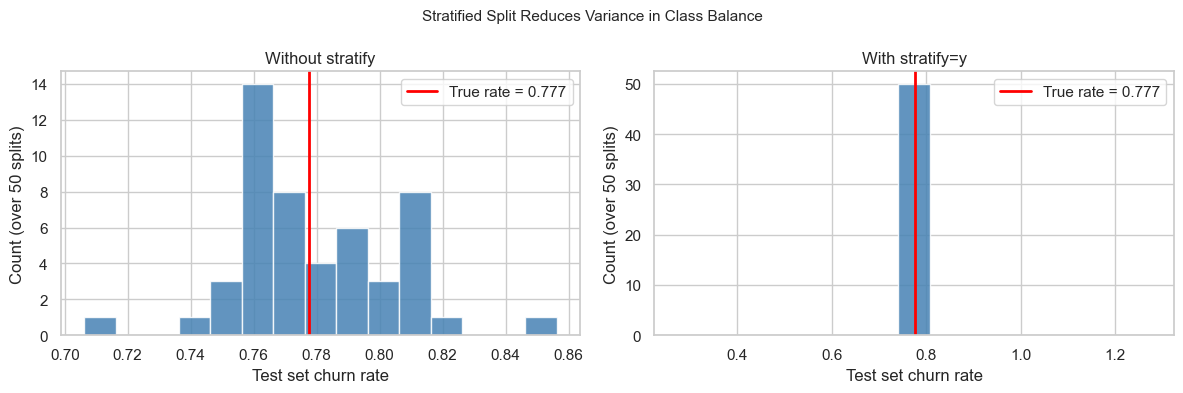

In [4]:
# Why stratification matters
print('Effect of stratification on class balance:')
print()

for stratify, label in [(None, 'Without stratify'), (y, 'With stratify')]:
    np.random.seed(42)
    results = []
    for _ in range(20):  # run 20 random splits
        _, X_t, _, y_t = train_test_split(X, y, test_size=0.2, stratify=stratify)
        results.append(y_t.mean())

    overall_rate = y.mean()
    print(f'  {label}:')
    print(f'    True churn rate:     {overall_rate*100:.1f}%')
    print(f'    Test set churn rate: {np.mean(results)*100:.1f}% ± {np.std(results)*100:.2f}%')
    print()

# Visual
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, strat, title in [
    (axes[0], None, 'Without stratify'),
    (axes[1], y,    'With stratify=y'),
]:
    rates = []
    for seed in range(50):
        _, _, _, y_t = train_test_split(X, y, test_size=0.2, random_state=seed, stratify=strat)
        rates.append(y_t.mean())

    ax.hist(rates, bins=15, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(y.mean(), color='red', lw=2, label=f'True rate = {y.mean():.3f}')
    ax.set_xlabel('Test set churn rate')
    ax.set_ylabel('Count (over 50 splits)')
    ax.set_title(title)
    ax.legend()

plt.suptitle('Stratified Split Reduces Variance in Class Balance', fontsize=11)
plt.tight_layout()
plt.show()

---
## 3. K-Fold Cross-Validation

A single train/test split gives us **one** estimate of performance. That estimate has high variance — it depends on which samples ended up in the test set.

**K-Fold CV** gives us $k$ estimates, uses all data for testing, and averages:

```
k=5 folds:
  Fold 1: [  TEST  ] [     TRAIN (folds 2-5)     ]
  Fold 2: [ TRAIN  ] [  TEST  ] [   TRAIN (3-5)  ]
  Fold 3: [ TRAIN (1-2)] [ TEST ] [  TRAIN (4-5) ]
  Fold 4: [ TRAIN (1-3)   ] [ TEST ] [ TRAIN 5   ]
  Fold 5: [ TRAIN (folds 1-4)     ] [   TEST     ]

→ Report: mean ± std across 5 test scores
```

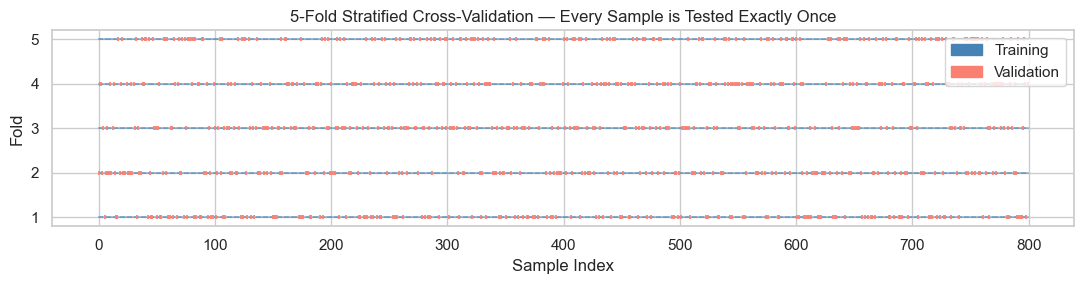

                    Model    CV Mean     CV Std   95% CI              
─────────────────────────────────────────────────────────────────
      Logistic Regression     0.9125     0.0354   [0.8815, 0.9435]
            Decision Tree     0.8713     0.0273   [0.8473, 0.8952]
                KNN (k=7)     0.8875     0.0125   [0.8765, 0.8985]
              Naive Bayes     0.8812     0.0379   [0.8480, 0.9145]


In [5]:
# Visualise k-fold splits
n_samples = len(X)
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fig, ax = plt.subplots(figsize=(11, 3))

for fold_idx, (train_idx, test_idx) in enumerate(kf.split(X, y)):
    ax.scatter(train_idx, [fold_idx + 1] * len(train_idx),
               c='steelblue', s=3, alpha=0.4, marker='|')
    ax.scatter(test_idx, [fold_idx + 1] * len(test_idx),
               c='salmon', s=6, alpha=0.9, marker='|')

from matplotlib.patches import Patch
ax.legend(handles=[Patch(color='steelblue', label='Training'),
                   Patch(color='salmon',    label='Validation')],
          loc='upper right')
ax.set_xlabel('Sample Index')
ax.set_ylabel('Fold')
ax.set_yticks([1, 2, 3, 4, 5])
ax.set_title('5-Fold Stratified Cross-Validation — Every Sample is Tested Exactly Once')
plt.tight_layout()
plt.show()

# Run CV on multiple models
models = {
    'Logistic Regression': Pipeline([('sc', StandardScaler()), ('lr', LogisticRegression(max_iter=500))]),
    'Decision Tree':        DecisionTreeClassifier(max_depth=5, random_state=42),
    'KNN (k=7)':           Pipeline([('sc', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=7))]),
    'Naive Bayes':          GaussianNB(),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f"{'Model':>25}   {'CV Mean':>8}   {'CV Std':>8}   {'95% CI':<20}")
print('─' * 65)

cv_results = {}
for name, mdl in models.items():
    scores = cross_val_score(mdl, X, y, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    ci_lo = scores.mean() - 1.96 * scores.std() / np.sqrt(len(scores))
    ci_hi = scores.mean() + 1.96 * scores.std() / np.sqrt(len(scores))
    print(f"{name:>25}   {scores.mean():>8.4f}   {scores.std():>8.4f}   [{ci_lo:.4f}, {ci_hi:.4f}]")

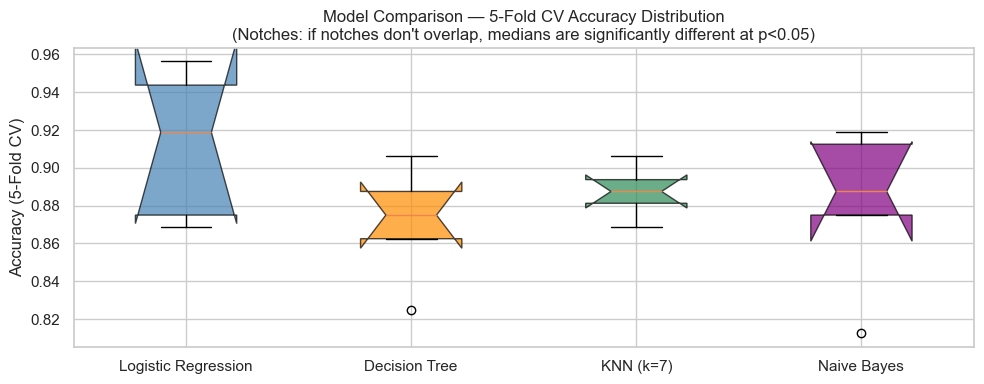

Use boxes, not just the mean — the spread (variance) tells you how stable each model is.


In [6]:
# Box plot of CV scores
fig, ax = plt.subplots(figsize=(10, 4))

all_scores = list(cv_results.values())
all_names  = list(cv_results.keys())

bp = ax.boxplot(all_scores, labels=all_names, patch_artist=True, notch=True)
colours = ['steelblue', 'darkorange', 'seagreen', 'purple']
for patch, colour in zip(bp['boxes'], colours):
    patch.set_facecolor(colour)
    patch.set_alpha(0.7)

ax.set_ylabel('Accuracy (5-Fold CV)')
ax.set_title('Model Comparison — 5-Fold CV Accuracy Distribution\n'
             '(Notches: if notches don\'t overlap, medians are significantly different at p<0.05)')
plt.tight_layout()
plt.show()

print('Use boxes, not just the mean — the spread (variance) tells you how stable each model is.')

---
## 4. Stratified & Repeated Cross-Validation

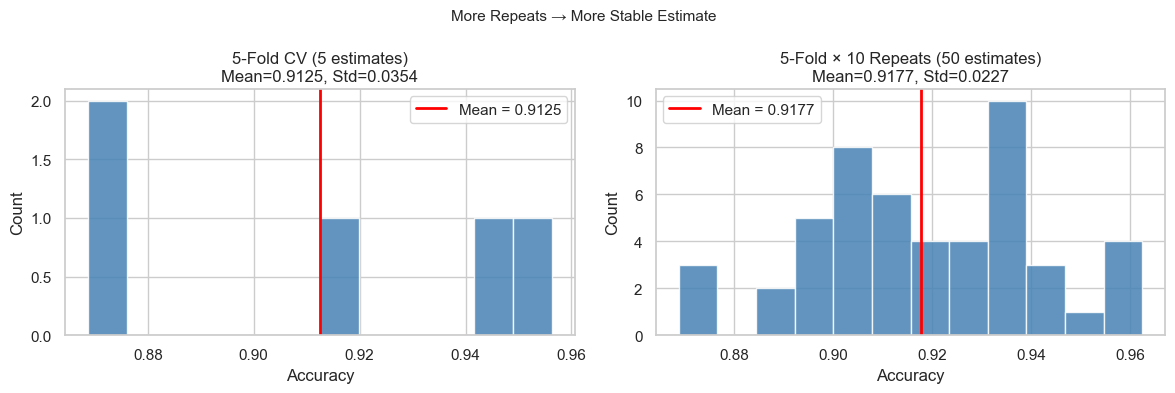

Repeated CV reduces the variance of the performance estimate.
Use when you want high confidence in your model comparison.


In [7]:
# Repeated K-Fold: run k-fold multiple times with different shuffles → even more stable estimate
rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)

model_to_compare = Pipeline([('sc', StandardScaler()), ('lr', LogisticRegression(max_iter=500))])

scores_5fold  = cross_val_score(model_to_compare, X, y,
                                cv=StratifiedKFold(5, shuffle=True, random_state=42),
                                scoring='accuracy')
scores_5x10   = cross_val_score(model_to_compare, X, y, cv=rkf, scoring='accuracy')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, scores, title in [
    (axes[0], scores_5fold, '5-Fold CV (5 estimates)'),
    (axes[1], scores_5x10,  '5-Fold × 10 Repeats (50 estimates)'),
]:
    ax.hist(scores, bins=12, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(scores.mean(), color='red', lw=2, label=f'Mean = {scores.mean():.4f}')
    ax.set_xlabel('Accuracy')
    ax.set_ylabel('Count')
    ax.set_title(f'{title}\nMean={scores.mean():.4f}, Std={scores.std():.4f}')
    ax.legend()

plt.suptitle('More Repeats → More Stable Estimate', fontsize=11)
plt.tight_layout()
plt.show()

print('Repeated CV reduces the variance of the performance estimate.')
print('Use when you want high confidence in your model comparison.')

---
## 5. Regression Metrics

| Metric | Formula | Unit | When to prefer |
|---|---|---|---|
| **MSE** | $\frac{1}{n}\sum(y_i - \hat{y}_i)^2$ | Target² | Penalises large errors; used in loss functions |
| **RMSE** | $\sqrt{\text{MSE}}$ | Target | Most interpretable; same unit as target |
| **MAE** | $\frac{1}{n}\sum\|y_i - \hat{y}_i\|$ | Target | Robust to outliers; intuitive |
| **MAPE** | $\frac{1}{n}\sum\|\frac{y_i - \hat{y}_i}{y_i}\|$ | % | When relative error matters more |
| **R²** | $1 - \frac{\sum(y_i-\hat{y}_i)^2}{\sum(y_i-\bar{y})^2}$ | — | Fraction of variance explained |

Linear Regression — Monthly Charges Prediction:
  MSE:       383.5174  (avg squared error in $²)
  RMSE:       19.5836  (avg error in $, same unit as target)
  MAE:        15.8217  (avg absolute error in $)
  MAPE:         29.10%  (avg relative error)
  R²:          0.0044  (0.4% variance explained)
  Adj. R²:    -0.0160  (penalised for 4 features)


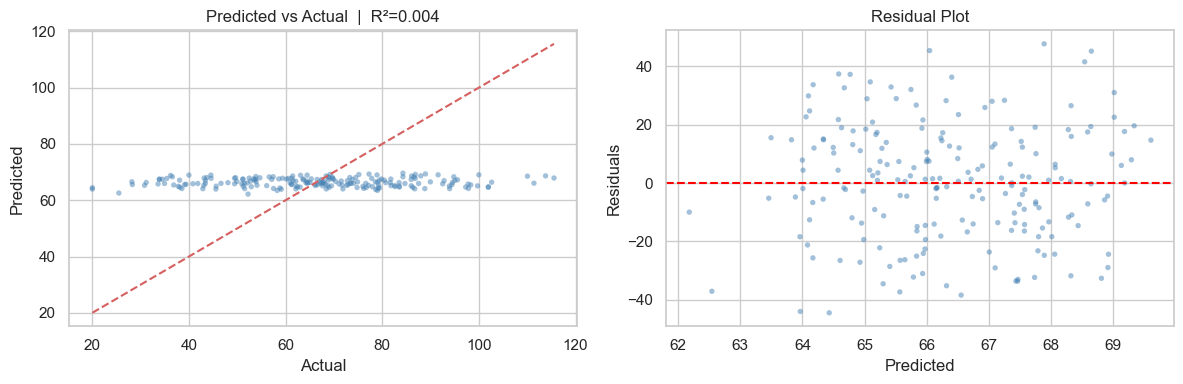

In [8]:
# Regression scenario: predict monthly_charges from other features
X_reg = df[['tenure', 'num_services', 'support_calls', 'contract_type']].values
y_reg = df['monthly_charges'].values

Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_reg, y_reg, test_size=0.25, random_state=42)

# Two regression models
lr = Pipeline([('sc', StandardScaler()), ('lr', LinearRegression())])
lr.fit(Xr_tr, yr_tr)
yr_pred = lr.predict(Xr_te)

mse  = mean_squared_error(yr_te, yr_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(yr_te, yr_pred)
mape = mean_absolute_percentage_error(yr_te, yr_pred) * 100
r2   = r2_score(yr_te, yr_pred)

n, p = len(Xr_te), Xr_tr.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print('Linear Regression — Monthly Charges Prediction:')
print(f'  MSE:     {mse:>10.4f}  (avg squared error in $²)')
print(f'  RMSE:    {rmse:>10.4f}  (avg error in $, same unit as target)')
print(f'  MAE:     {mae:>10.4f}  (avg absolute error in $)')
print(f'  MAPE:    {mape:>10.2f}%  (avg relative error)')
print(f'  R²:      {r2:>10.4f}  ({r2*100:.1f}% variance explained)')
print(f'  Adj. R²: {adj_r2:>10.4f}  (penalised for {p} features)')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(yr_te, yr_pred, alpha=0.5, color='steelblue', s=15, edgecolors='none')
lims = [min(yr_te.min(), yr_pred.min()), max(yr_te.max(), yr_pred.max())]
axes[0].plot(lims, lims, 'r--', lw=1.5)
axes[0].set_xlabel('Actual')
axes[0].set_ylabel('Predicted')
axes[0].set_title(f'Predicted vs Actual  |  R²={r2:.3f}')

residuals = yr_te - yr_pred
axes[1].scatter(yr_pred, residuals, alpha=0.5, color='steelblue', s=15, edgecolors='none')
axes[1].axhline(0, color='red', lw=1.5, ls='--')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residuals')
axes[1].set_title('Residual Plot')

plt.tight_layout()
plt.show()

---
## 6. Classification Metrics

In [9]:
# Full classification evaluation
Xc_tr, Xc_te, yc_tr, yc_te = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

logr = Pipeline([('sc', StandardScaler()), ('lr', LogisticRegression(max_iter=500))])
logr.fit(Xc_tr, yc_tr)

yc_pred = logr.predict(Xc_te)
yc_prob = logr.predict_proba(Xc_te)[:, 1]

tn, fp, fn, tp = confusion_matrix(yc_te, yc_pred).ravel()

acc   = (tp + tn) / (tp + tn + fp + fn)
prec  = tp / (tp + fp) if (tp + fp) > 0 else 0
rec   = tp / (tp + fn) if (tp + fn) > 0 else 0
spec  = tn / (tn + fp) if (tn + fp) > 0 else 0  # specificity
f1    = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
mcc   = matthews_corrcoef(yc_te, yc_pred)
auc   = roc_auc_score(yc_te, yc_prob)
brier = brier_score_loss(yc_te, yc_prob)
ll    = log_loss(yc_te, yc_prob)

print('Comprehensive Classification Report:')
print()
print(f'  Confusion Matrix:  TN={tn}  FP={fp}  FN={fn}  TP={tp}')
print()
print(f'  Accuracy:          {acc:.4f}  (overall correct rate)')
print(f'  Precision:         {prec:.4f}  (of predicted churn, fraction truly churned)')
print(f'  Recall (Sens.):    {rec:.4f}  (of all churners, fraction we caught)')
print(f'  Specificity:       {spec:.4f}  (of non-churners, fraction correctly identified)')
print(f'  F1 Score:          {f1:.4f}  (harmonic mean of precision and recall)')
print(f'  MCC:               {mcc:.4f}  (Matthews Correlation: balanced, even for imbalanced data)')
print(f'  AUC-ROC:           {auc:.4f}  (threshold-independent ranking quality)')
print(f'  Brier Score:       {brier:.4f}  (mean squared probability error — lower is better)')
print(f'  Log Loss:          {ll:.4f}  (cross-entropy of predicted probs — lower is better)')

Comprehensive Classification Report:

  Confusion Matrix:  TN=34  FP=11  FN=6  TP=149

  Accuracy:          0.9150  (overall correct rate)
  Precision:         0.9313  (of predicted churn, fraction truly churned)
  Recall (Sens.):    0.9613  (of all churners, fraction we caught)
  Specificity:       0.7556  (of non-churners, fraction correctly identified)
  F1 Score:          0.9460  (harmonic mean of precision and recall)
  MCC:               0.7484  (Matthews Correlation: balanced, even for imbalanced data)
  AUC-ROC:           0.9753  (threshold-independent ranking quality)
  Brier Score:       0.0556  (mean squared probability error — lower is better)
  Log Loss:          0.1727  (cross-entropy of predicted probs — lower is better)


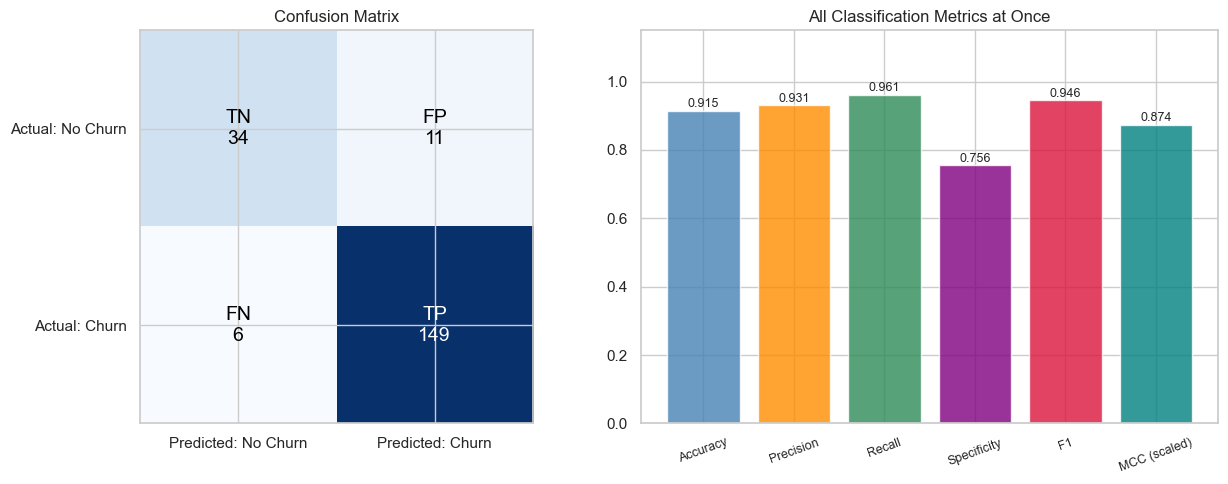

In [10]:
# Visualise confusion matrix with full annotations
cm = confusion_matrix(yc_te, yc_pred)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Annotated confusion matrix
cm_labels = np.array([
    [f'TN\n{cm[0,0]}', f'FP\n{cm[0,1]}'],
    [f'FN\n{cm[1,0]}', f'TP\n{cm[1,1]}']
])

im = axes[0].imshow(cm, cmap='Blues')
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm_labels[i, j], ha='center', va='center',
                     fontsize=14, color='white' if cm[i, j] > cm.max()/2 else 'black')
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Predicted: No Churn', 'Predicted: Churn'])
axes[0].set_yticklabels(['Actual: No Churn', 'Actual: Churn'])
axes[0].set_title('Confusion Matrix')

# Metric spider/bar chart
metric_names  = ['Accuracy', 'Precision', 'Recall', 'Specificity', 'F1', 'MCC (scaled)']
metric_values = [acc, prec, rec, spec, f1, (mcc + 1) / 2]  # scale MCC to [0,1]
colours = ['steelblue', 'darkorange', 'seagreen', 'purple', 'crimson', 'teal']

bars = axes[1].bar(metric_names, metric_values, color=colours, alpha=0.8, edgecolor='white')
axes[1].set_ylim(0, 1.15)
axes[1].set_title('All Classification Metrics at Once')
axes[1].tick_params(axis='x', rotation=20, labelsize=9)
for bar, val in zip(bars, metric_values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.3f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

---
## 7. The ROC/PR Tradeoff — When to Use Which

| Curve | X-axis | Y-axis | Use when |
|---|---|---|---|
| **ROC** | FPR (1 - Specificity) | TPR (Recall) | Balanced or near-balanced classes |
| **PR** | Recall | Precision | Highly imbalanced classes |

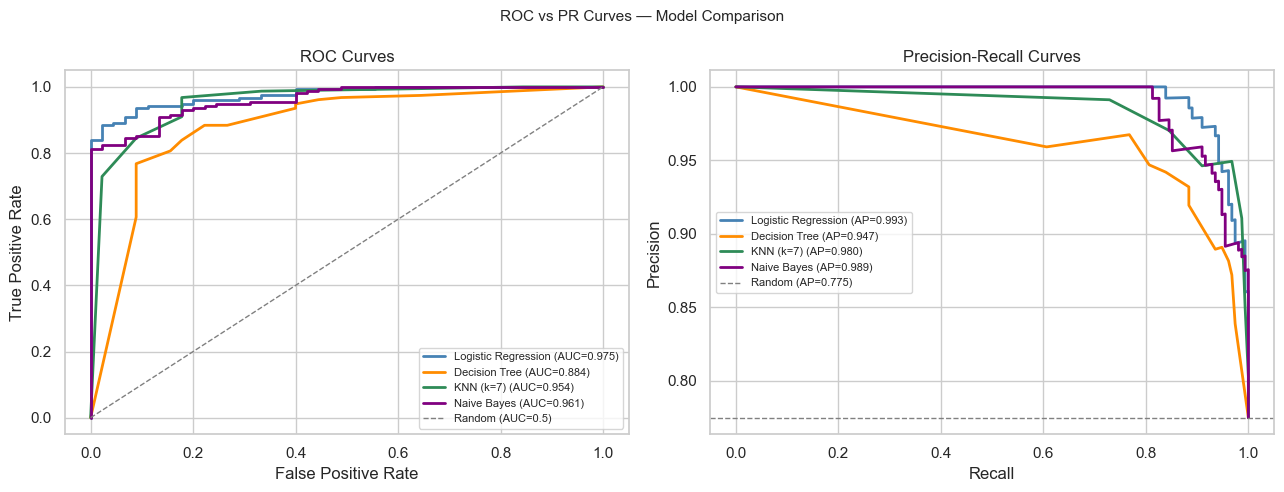

ROC curve: tells you ranking quality regardless of threshold
PR curve:  more informative for imbalanced datasets (minority class is the positive class)


In [11]:
# Compare multiple models on ROC and PR curves
model_probs = {}
for name, mdl in models.items():
    mdl.fit(Xc_tr, yc_tr)
    model_probs[name] = mdl.predict_proba(Xc_te)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colours_m = ['steelblue', 'darkorange', 'seagreen', 'purple']

for (name, probs), colour in zip(model_probs.items(), colours_m):
    # ROC curve
    fpr, tpr, _ = roc_curve(yc_te, probs)
    auc_val = roc_auc_score(yc_te, probs)
    axes[0].plot(fpr, tpr, color=colour, lw=2, label=f'{name} (AUC={auc_val:.3f})')

    # PR curve
    prec_c, rec_c, _ = precision_recall_curve(yc_te, probs)
    ap = average_precision_score(yc_te, probs)
    axes[1].plot(rec_c, prec_c, color=colour, lw=2, label=f'{name} (AP={ap:.3f})')

# ROC random baseline
axes[0].plot([0, 1], [0, 1], 'gray', lw=1, ls='--', label='Random (AUC=0.5)')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves')
axes[0].legend(fontsize=8)

# PR random baseline
baseline_pr = yc_te.mean()
axes[1].axhline(baseline_pr, color='gray', lw=1, ls='--',
               label=f'Random (AP={baseline_pr:.3f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves')
axes[1].legend(fontsize=8)

plt.suptitle('ROC vs PR Curves — Model Comparison', fontsize=11)
plt.tight_layout()
plt.show()

print('ROC curve: tells you ranking quality regardless of threshold')
print('PR curve:  more informative for imbalanced datasets (minority class is the positive class)')

---
## 8. Calibration — Are Probabilities Trustworthy?

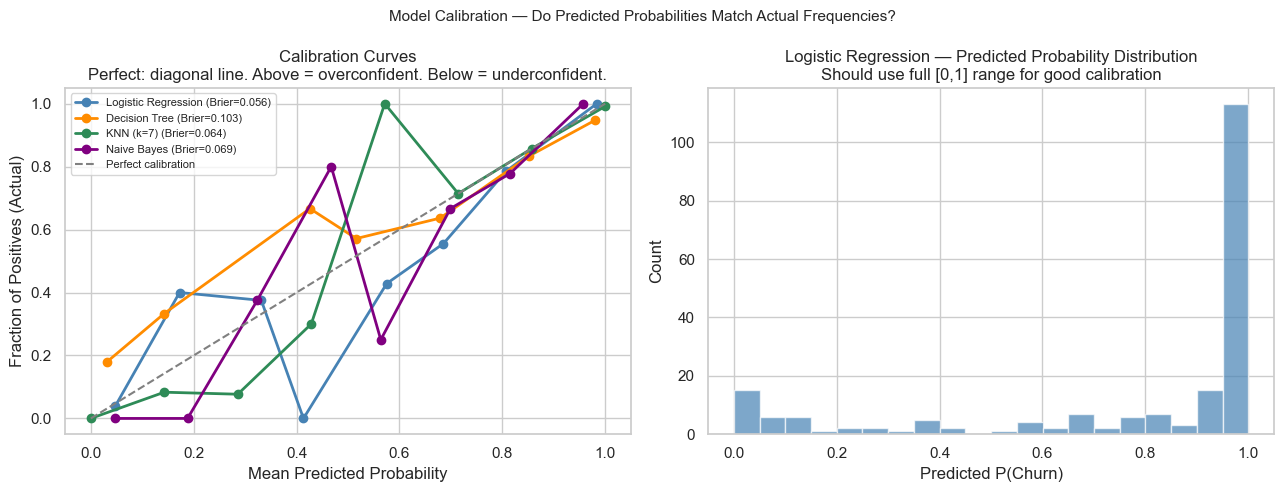

Calibration matters when you use probabilities for business decisions.
Example: if model says P(churn)=0.8 for 100 customers, ~80 should actually churn.
If only 40 do → model is poorly calibrated → misleading risk scores.


In [12]:
# A well-calibrated model: P(y=1|score=0.7) ≈ 70% of the time
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Calibration curves for our models
for (name, probs), colour in zip(model_probs.items(), colours_m):
    fraction_of_positives, mean_predicted_value = calibration_curve(
        yc_te, probs, n_bins=8
    )
    brier = brier_score_loss(yc_te, probs)
    axes[0].plot(mean_predicted_value, fraction_of_positives,
                 color=colour, lw=2, marker='o', ms=6,
                 label=f'{name} (Brier={brier:.3f})')

axes[0].plot([0, 1], [0, 1], 'gray', ls='--', lw=1.5, label='Perfect calibration')
axes[0].set_xlabel('Mean Predicted Probability')
axes[0].set_ylabel('Fraction of Positives (Actual)')
axes[0].set_title('Calibration Curves\n'
                  'Perfect: diagonal line. Above = overconfident. Below = underconfident.')
axes[0].legend(fontsize=8)

# Histogram of predicted probabilities
axes[1].hist(model_probs['Logistic Regression'], bins=20,
             color='steelblue', edgecolor='white', alpha=0.7)
axes[1].set_xlabel('Predicted P(Churn)')
axes[1].set_ylabel('Count')
axes[1].set_title('Logistic Regression — Predicted Probability Distribution\n'
                  'Should use full [0,1] range for good calibration')

plt.suptitle('Model Calibration — Do Predicted Probabilities Match Actual Frequencies?', fontsize=11)
plt.tight_layout()
plt.show()

print('Calibration matters when you use probabilities for business decisions.')
print('Example: if model says P(churn)=0.8 for 100 customers, ~80 should actually churn.')
print('If only 40 do → model is poorly calibrated → misleading risk scores.')

---
## 9. Learning Curves

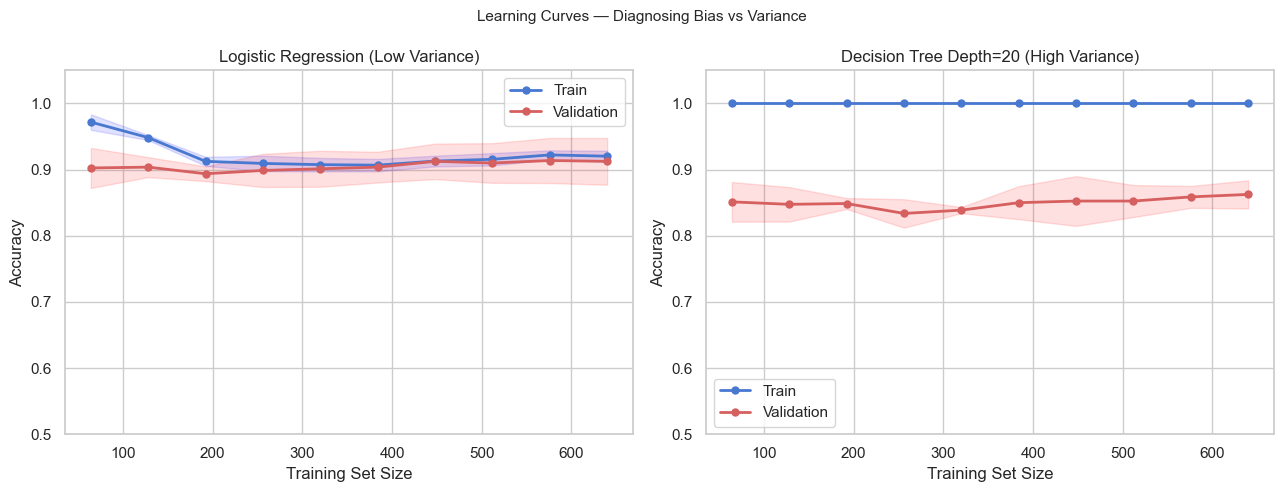

Learning curve patterns:
  High Bias (underfitting):   both curves plateau at LOW accuracy → add more features
  High Variance (overfitting): large GAP between train and val → more data or regularise
  Good fit:                   curves converge to HIGH accuracy → balanced model


In [13]:
# Learning curves for two models: Logistic Regression vs Decision Tree
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

models_lc = [
    ('Logistic Regression (Low Variance)', 
     Pipeline([('sc', StandardScaler()), ('lr', LogisticRegression(max_iter=500))])),
    ('Decision Tree Depth=20 (High Variance)',
     DecisionTreeClassifier(max_depth=20, random_state=42)),
]

for ax, (name, mdl) in zip(axes, models_lc):
    train_sizes, tr_scores, val_scores = learning_curve(
        mdl, X, y,
        train_sizes=np.linspace(0.1, 1.0, 10),
        cv=StratifiedKFold(5, shuffle=True, random_state=42),
        scoring='accuracy',
        n_jobs=-1
    )

    tr_mean, tr_std = tr_scores.mean(1), tr_scores.std(1)
    vl_mean, vl_std = val_scores.mean(1), val_scores.std(1)

    ax.plot(train_sizes, tr_mean, 'b-o', lw=2, ms=5, label='Train')
    ax.fill_between(train_sizes, tr_mean - tr_std, tr_mean + tr_std, alpha=0.12, color='blue')

    ax.plot(train_sizes, vl_mean, 'r-o', lw=2, ms=5, label='Validation')
    ax.fill_between(train_sizes, vl_mean - vl_std, vl_mean + vl_std, alpha=0.12, color='red')

    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('Accuracy')
    ax.set_title(name)
    ax.legend()
    ax.set_ylim(0.5, 1.05)

plt.suptitle('Learning Curves — Diagnosing Bias vs Variance', fontsize=11)
plt.tight_layout()
plt.show()

print('Learning curve patterns:')
print('  High Bias (underfitting):   both curves plateau at LOW accuracy → add more features')
print('  High Variance (overfitting): large GAP between train and val → more data or regularise')
print('  Good fit:                   curves converge to HIGH accuracy → balanced model')

---
## 10. Validation Curves

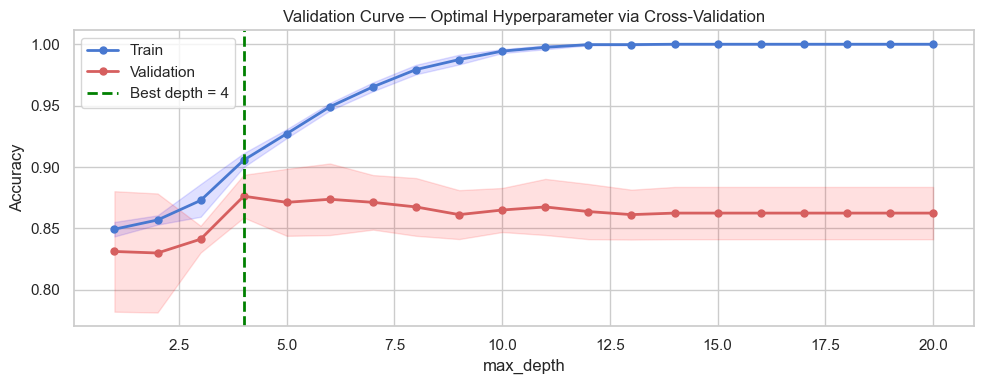

Optimal max_depth = 4  (validation accuracy = 0.8762)


In [14]:
# Validation curve: Decision Tree depth
param_range = range(1, 21)

train_scores_vc, val_scores_vc = validation_curve(
    DecisionTreeClassifier(random_state=42),
    X, y,
    param_name='max_depth',
    param_range=param_range,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='accuracy'
)

fig, ax = plt.subplots(figsize=(10, 4))

tr_m, tr_s = train_scores_vc.mean(1), train_scores_vc.std(1)
vl_m, vl_s = val_scores_vc.mean(1),   val_scores_vc.std(1)

ax.plot(list(param_range), tr_m, 'b-o', lw=2, ms=5, label='Train')
ax.fill_between(param_range, tr_m - tr_s, tr_m + tr_s, alpha=0.12, color='blue')

ax.plot(list(param_range), vl_m, 'r-o', lw=2, ms=5, label='Validation')
ax.fill_between(param_range, vl_m - vl_s, vl_m + vl_s, alpha=0.12, color='red')

best_d = list(param_range)[np.argmax(vl_m)]
ax.axvline(best_d, color='green', ls='--', lw=2, label=f'Best depth = {best_d}')
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.set_title('Validation Curve — Optimal Hyperparameter via Cross-Validation')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Optimal max_depth = {best_d}  (validation accuracy = {vl_m[best_d-1]:.4f})')

---
## 11. Hyperparameter Tuning — Grid vs Random Search

In [15]:
from scipy.stats import randint, uniform

# Grid Search
param_grid = {
    'max_depth':        [3, 5, 7, 10],
    'min_samples_leaf': [5, 10, 20],
    'criterion':        ['gini', 'entropy'],
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1
)
grid_search.fit(Xc_tr, yc_tr)

# Random Search
param_dist = {
    'max_depth':        randint(2, 20),
    'min_samples_leaf': randint(2, 50),
    'criterion':        ['gini', 'entropy'],
}

random_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_dist,
    n_iter=40,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='accuracy',
    random_state=42,
    n_jobs=-1
)
random_search.fit(Xc_tr, yc_tr)

print('Hyperparameter Tuning Results:')
print()
print(f'Grid Search ({len(grid_search.cv_results_["params"])} combinations):')
print(f'  Best params: {grid_search.best_params_}')
print(f'  Best CV score: {grid_search.best_score_:.4f}')
print(f'  Test accuracy: {grid_search.score(Xc_te, yc_te):.4f}')
print()
print(f'Random Search (40 iterations):')
print(f'  Best params: {random_search.best_params_}')
print(f'  Best CV score: {random_search.best_score_:.4f}')
print(f'  Test accuracy: {random_search.score(Xc_te, yc_te):.4f}')
print()
print('Random Search often finds equally good results in fewer evaluations.')
print('Rule of thumb: use Random Search when you have many hyperparameters (>3).')

Hyperparameter Tuning Results:

Grid Search (24 combinations):
  Best params: {'criterion': 'gini', 'max_depth': 7, 'min_samples_leaf': 10}
  Best CV score: 0.8600
  Test accuracy: 0.9100

Random Search (40 iterations):
  Best params: {'criterion': 'gini', 'max_depth': 8, 'min_samples_leaf': 10}
  Best CV score: 0.8600
  Test accuracy: 0.9100

Random Search often finds equally good results in fewer evaluations.
Rule of thumb: use Random Search when you have many hyperparameters (>3).


---
## 12. Data Leakage — The Silent Killer

Data leakage is when information from the **test set** (or future data) leaks into the training process. It causes unrealistically optimistic evaluation — your model looks great in development but fails in production.

### Common leakage sources:
1. **Preprocessing leakage:** Fitting a scaler/imputer on the full dataset before splitting
2. **Target leakage:** Using features that are only available after the outcome occurs
3. **Temporal leakage:** Training on future data to predict the past
4. **Duplicate leakage:** Same observations appear in both train and test sets

In [16]:
# Demonstrate preprocessing leakage
print('Preprocessing Leakage Demonstration:')
print('=' * 50)
print()

# WRONG: fit scaler on all data before splitting
scaler_leaked = StandardScaler()
X_all_scaled  = scaler_leaked.fit_transform(X)   # uses test data statistics!
X_tr_l, X_te_l, y_tr_l, y_te_l = train_test_split(X_all_scaled, y, test_size=0.25, random_state=42)

knn_leaked = KNeighborsClassifier(n_neighbors=7)
knn_leaked.fit(X_tr_l, y_tr_l)
acc_leaked = accuracy_score(y_te_l, knn_leaked.predict(X_te_l))

# CORRECT: split first, then fit scaler on training data only
X_tr_c, X_te_c, y_tr_c, y_te_c = train_test_split(X, y, test_size=0.25, random_state=42)

knn_correct = Pipeline([
    ('scaler', StandardScaler()),          # fit() only sees training data
    ('knn', KNeighborsClassifier(n_neighbors=7))
])
knn_correct.fit(X_tr_c, y_tr_c)
acc_correct = accuracy_score(y_te_c, knn_correct.predict(X_te_c))

print(f'  WRONG (scaler fit on all data): Test Accuracy = {acc_leaked:.4f}  ← inflated!')
print(f'  CORRECT (pipeline, split first): Test Accuracy = {acc_correct:.4f}  ← reliable')
print()
print(f'  Leakage inflation: {(acc_leaked - acc_correct)*100:+.2f}% accuracy points')
print()
print('Rule: ALWAYS use Pipeline so preprocessing is applied correctly.')
print('The Pipeline automatically fits transformers only on training data.')

Preprocessing Leakage Demonstration:

  WRONG (scaler fit on all data): Test Accuracy = 0.8850  ← inflated!
  CORRECT (pipeline, split first): Test Accuracy = 0.8900  ← reliable

  Leakage inflation: -0.50% accuracy points

Rule: ALWAYS use Pipeline so preprocessing is applied correctly.
The Pipeline automatically fits transformers only on training data.


---
## 13. Statistical Significance of Model Differences

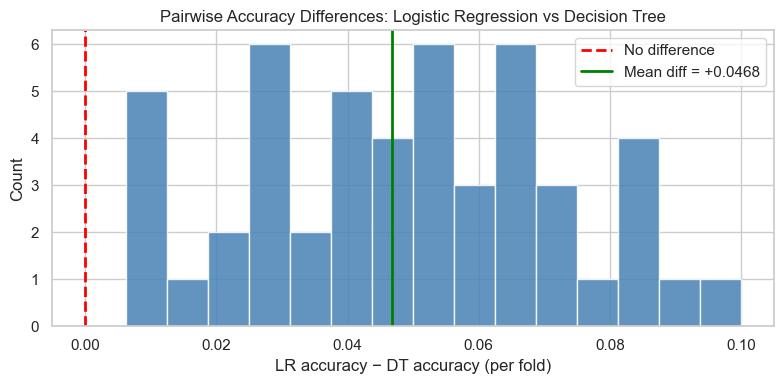

Paired t-test results:
  Logistic Regression mean accuracy: 0.9177 ± 0.0227
  Decision Tree mean accuracy:       0.8710 ± 0.0249
  Mean difference: +0.0468
  t-statistic: 13.890
  p-value: 0.0000

  Conclusion: Difference IS statistically significant (p < 0.05) → Logistic Regression is better


In [17]:
# Paired t-test: is the difference between two models statistically significant?
cv_lr = cross_val_score(
    Pipeline([('sc', StandardScaler()), ('lr', LogisticRegression(max_iter=500))]),
    X, y, cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
)
cv_dt = cross_val_score(
    DecisionTreeClassifier(max_depth=best_d, random_state=42),
    X, y, cv=RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=42)
)

# Paired t-test (each pair of scores comes from the same fold)
t_stat, p_value = stats.ttest_rel(cv_lr, cv_dt)
diff = cv_lr - cv_dt

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(diff, bins=15, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(0, color='red', lw=2, ls='--', label='No difference')
ax.axvline(diff.mean(), color='green', lw=2, label=f'Mean diff = {diff.mean():+.4f}')
ax.set_xlabel('LR accuracy − DT accuracy (per fold)')
ax.set_ylabel('Count')
ax.set_title('Pairwise Accuracy Differences: Logistic Regression vs Decision Tree')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Paired t-test results:')
print(f'  Logistic Regression mean accuracy: {cv_lr.mean():.4f} ± {cv_lr.std():.4f}')
print(f'  Decision Tree mean accuracy:       {cv_dt.mean():.4f} ± {cv_dt.std():.4f}')
print(f'  Mean difference: {diff.mean():+.4f}')
print(f'  t-statistic: {t_stat:.3f}')
print(f'  p-value: {p_value:.4f}')
print()
if p_value < 0.05:
    winner = 'Logistic Regression' if cv_lr.mean() > cv_dt.mean() else 'Decision Tree'
    print(f'  Conclusion: Difference IS statistically significant (p < 0.05) → {winner} is better')
else:
    print(f'  Conclusion: Difference is NOT statistically significant (p = {p_value:.4f})')
    print('  The models perform equivalently — choose based on interpretability or speed.')

---
## 14. Summary — The Evaluation Checklist

### Before you evaluate:
- [ ] Split data BEFORE any preprocessing
- [ ] Use `stratify=y` for classification
- [ ] Use a Pipeline so preprocessing never sees test data
- [ ] Define your primary metric based on the business problem

### Choosing metrics:

| Situation | Primary metric | Why |
|---|---|---|
| Balanced classes, any error equally bad | Accuracy / F1 | Simple and interpretable |
| Imbalanced classes | AUC-ROC, F1 of minority class | Accuracy is misleading |
| Missing a positive is very costly (disease, fraud) | Recall | Minimise FN |
| False alarms are costly | Precision | Minimise FP |
| Need calibrated probabilities | Brier Score, Log Loss | Measures probability quality |
| Regression, outliers present | MAE | Less sensitive than RMSE |
| Regression, large errors are catastrophic | RMSE | Penalises large errors heavily |

### Cross-validation guide:

| Situation | CV method |
|---|---|
| General case | 5-Fold or 10-Fold Stratified CV |
| Small dataset | Leave-One-Out (LOO) |
| Need stable estimate | Repeated Stratified K-Fold (5×10) |
| Time series | TimeSeriesSplit (forward chaining) |

---
**Remember:** A model comparison is only valid if both models were evaluated on the **same data** using the **same CV splits** and tested for **statistical significance**.